In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import chess
import chess.svg
import random
import time
import math
import csv
from tqdm import tqdm
from pathlib import Path
from IPython.display import display, SVG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
MODEL_DIR = Path("models")
LOGS_DIR = Path("experiments/logs")
DATASET_READY_DIR = Path("./dataset_ready/train/train_balanced.parquet")

In [15]:
# ==========================================
# Configuration
# ==========================================
class Config:
    # Models to train in this run, eg. ACTIVE_PROBES = ["TRANSFORMER_8H", "TRANSFORMER_4H", "CNN", "MLP"]
    ACTIVE_PROBES = ["RAW_BITMAPS"]
    # chess.BISHOP, chess.ROOK, chess.QUEEN
    PROBE_PIECES = [chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN] 
    
    # Control the BCE Loss positive weight for class imbalance
    PIECE_WEIGHTS = {
        chess.KNIGHT: 10.0,
        chess.BISHOP: 10.0,
        chess.ROOK: 6.0,
        chess.QUEEN: 4.0,
        # chess.PAWN: 2.0, 
        # chess.KING: 20.0 
    }

    # Training Hyperparameters
    EPOCHS = 10
    LEARNING_RATE = 1e-3
    
    # Inference / Visualization Settings
    TEST_FEN = "2r2r2/2p1qpk1/p1np3p/1p4p1/4P3/Q3N1bP/P2K2P1/2R2B2 w - - 0 1"
    TARGET_SQUARE = None # Set to None for a random piece

MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"in_channels": 19, "channels": 64, "num_blocks": 16, "num_classes": 7}
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "model_kwargs": {"input_shape": 775, "output_shape": 7}
    },
    "TRANSFORMER_4H": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"input_channels": 19, "embed_dim": 128, "num_heads": 4, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    },
    "TRANSFORMER_8H": {
        "name": "transformer_v2",
        "dataset_dir": Path("./dataset_planes_cp/"), 
        "is_3d": True,
        "model_kwargs": {"input_channels": 19, "embed_dim": 256, "num_heads": 8, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    },
    "RAW_BITMAPS": {
        "name": "raw_bitmaps",
        "dataset_dir": Path("./dataset_bitmaps_cp/"), 
        "is_3d": False,
        "model_kwargs": {}
    }
}

In [16]:
# ==========================================
# Architectures
# ==========================================
# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [17]:
# ==========================================
# Utility Functions
# ==========================================
def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

def render_heatmap_svg(saliency_64, fen_str, title, display_svg=True):
    sal_min, sal_max = np.min(saliency_64), np.max(saliency_64)
    if sal_max > sal_min:
        saliency_norm = (saliency_64 - sal_min) / (sal_max - sal_min)
    else:
        saliency_norm = saliency_64

    cmap = plt.get_cmap("viridis")
    fill_dict = {i: mcolors.to_hex(cmap(saliency_norm[i]), keep_alpha=False) for i in range(64)}
    
    for square_idx in range(64):
        val = saliency_norm[square_idx]
        rgba = cmap(val)
        hex_color = mcolors.to_hex(rgba, keep_alpha=False)
        fill_dict[square_idx] = hex_color

    board_svg = chess.svg.board(
        chess.Board(fen_str),
        fill=fill_dict,
        size=350,
        coordinates=False,
        style=".square { stroke: white; stroke-width: 1.5px; }"
    )
    
    if display_svg:
        print(title)
        display(SVG(board_svg))

    return board_svg

def load_model(setup, model_key: str):
    if "CNN" in model_key:
        model = SEResNet(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif "MLP" in model_key:
        model = MLP(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif model_key in ["TRANSFORMER", "TRANSFORMER_4H", "TRANSFORMER_4H_PROBE", "TRANSFORMER_8H"]:
        model = Transformer(**setup["model_kwargs"]).to(DEVICE)
        return model

In [ ]:
# ==========================================
# Probing Dataset & Architecture
# ==========================================
class LegalMoveProbeDataset(Dataset):
    def __init__(self, npy_dir: Path, parquet_path: Path, split: str, piece_type: int):
        self.piece_type = piece_type
        self.npy_dir = Path(npy_dir)
        self.X = np.load(self.npy_dir / f"{split}_X.npy", mmap_mode='r')
        
        df = pd.read_parquet(parquet_path, columns=['fen'])
        self.fens = df['fen'].values
        assert len(self.X) == len(self.fens), f"Mismatch: {len(self.X)} tensors vs {len(self.fens)} FENs"

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        fen = str(self.fens[idx])
        board = chess.Board(fen)
        
        pieces = []
        for piece_type in [self.piece_type]:
            pieces.extend(list(board.pieces(piece_type, board.turn))) # collects all squares of pieces belonging to the side to move
            
        if not pieces:
            return x_tensor, torch.zeros(64, dtype=torch.float32), torch.zeros(64, dtype=torch.float32)
        
        target_square = random.choice(pieces)
        
        # one hot encoding of the square that contains the piece
        piece_loc_mask = np.zeros(64, dtype=np.float32)
        piece_loc_mask[target_square] = 1.0
        
        # one hot encodes all possible moves from the original square that contains piece
        legal_move_mask = np.zeros(64, dtype=np.float32)
        for move in board.legal_moves:
            if move.from_square == target_square:
                legal_move_mask[move.to_square] = 1.0
                
        return x_tensor, torch.tensor(piece_loc_mask), torch.tensor(legal_move_mask)
    
class LatentExtractor:
    def __init__(self, model, model_key):
        self.model = model.eval() 
        self.latent = None
        self.model_key = model_key
        self.handle = self._register_hook()

    def _register_hook(self):
        def hook_fn(module, input, output):
            # We grab the OUTPUT of these rich spatial layers!
            self.latent = output.detach()

        # CNN: Hook the bottleneck right before AdaptiveAvgPool2d (Output: [B, 32, 8, 8])
        if "CNN" in self.model_key:
            return self.model.bottleneck.register_forward_hook(hook_fn)
            
        # TRANSFORMER: Hook the final Encoder block right before x.mean() (Output: [B, 64, Embed_Dim])
        elif self.model_key in ["TRANSFORMER", "TRANSFORMER_4H", "TRANSFORMER_4H_PROBE", "TRANSFORMER_8H"]:
            return self.model.blocks[-1].register_forward_hook(hook_fn)
            
        # MLP: Hook the middle of the network before it bottlenecks too hard
        elif "MLP" in self.model_key:
            return self.model.network[7].register_forward_hook(hook_fn) 
            
        else:
            raise ValueError(f"Unknown model_key: {self.model_key}")

    def extract(self, x):
        with torch.no_grad():
            self.model(x)
        return self.latent
        
    def remove_hook(self):
        self.handle.remove()
        
class LegalMoveProbe(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.probe = nn.Linear(latent_dim + 64, 64)
        
    def forward(self, latent, query_one_hot):
        combined = torch.cat([latent, query_one_hot], dim=1)
        return self.probe(combined)

def train_probe_loop(base_model, model_key, probe, dataloader, pos_weight, epochs=10, lr=1e-3):
    print(f"Starting Probe Training on {DEVICE.upper()}...")

    if "RAW_BITMAPS" not in model_key:
        base_model.eval()
        extractor = LatentExtractor(base_model, model_key)
    
    weight = torch.tensor([pos_weight], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=weight)
    optimizer = torch.optim.AdamW(params=probe.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler(device=DEVICE)
    history = []
    
    for epoch in range(epochs):
        probe.train()
        total_loss, total_f1 = 0.0, 0.0

        loop = tqdm(dataloader, desc=f"Epoch [{epoch+1:02d}/{epochs}]", leave=True)

        for batch, (x_tensor, piece_loc_mask, legal_move_mask) in enumerate(loop):
            x_tensor, piece_loc_mask, legal_move_mask = x_tensor.to(DEVICE), piece_loc_mask.to(DEVICE), legal_move_mask.to(DEVICE)
                
            if "RAW_BITMAPS" in model_key:
                latent = x_tensor.flatten(1)
            else:
                latent = extractor.extract(x_tensor)
                if latent.dim() > 2:
                    latent = latent.flatten(1)

            optimizer.zero_grad()
            
            with torch.amp.autocast(DEVICE):
                predicted_moves_mask = probe(latent, piece_loc_mask) 
                loss = loss_fn(predicted_moves_mask, legal_move_mask)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
            with torch.no_grad():
                binary_preds_mask = (torch.sigmoid(predicted_moves_mask) > 0.5).float()
                tp = (binary_preds_mask * legal_move_mask).sum()
                fp = (binary_preds_mask * (1.0 - legal_move_mask)).sum()
                fn = ((1.0 - binary_preds_mask) * legal_move_mask).sum()
                f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
                total_f1 += f1.item()
            
            loop.set_postfix(loss=loss.item(), f1=f"{f1.item()*100:.2f}%")

        avg_loss = total_loss / len(dataloader)
        avg_f1 = total_f1 / len(dataloader) 
        history.append(avg_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_loss:.4f} | F1: {avg_f1*100:.2f}% | LR: {current_lr:.2e}\n")
        
    if "RAW_BITMAPS" not in model_key:
        extractor.remove_hook()
          
    return history, avg_f1


[RAW_BITMAPS] Setting up raw baseline...

Processing Probe: RAW_BITMAPS -> KNIGHT
[RAW_BITMAPS - knight] No probe found. Starting training...
Starting Probe Training on CUDA...


Epoch [01/10]: 100%|██████████| 8999/8999 [09:20<00:00, 16.05it/s, f1=94.31%, loss=0.0422]


Epoch [01/10] | Train Loss: 0.1698 | F1: 83.70% | LR: 1.00e-03



Epoch [02/10]: 100%|██████████| 8999/8999 [09:10<00:00, 16.34it/s, f1=94.74%, loss=0.0263]


Epoch [02/10] | Train Loss: 0.0349 | F1: 92.90% | LR: 9.76e-04



...

Epoch [08/10] | Train Loss: 0.0214 | F1: 95.95% | LR: 2.07e-04



Epoch [09/10]: 100%|██████████| 8999/8999 [09:46<00:00, 15.35it/s, f1=96.23%, loss=0.0153]


Epoch [09/10] | Train Loss: 0.0213 | F1: 95.97% | LR: 9.64e-05



Epoch [10/10]: 100%|██████████| 8999/8999 [09:47<00:00, 15.31it/s, f1=95.47%, loss=0.0244]


Epoch [10/10] | Train Loss: 0.0212 | F1: 95.97% | LR: 2.54e-05

[RAW_BITMAPS - knight] Logged Final F1: 95.97% to experiments\logs\raw_bitmaps\probe_f1_scores.csv


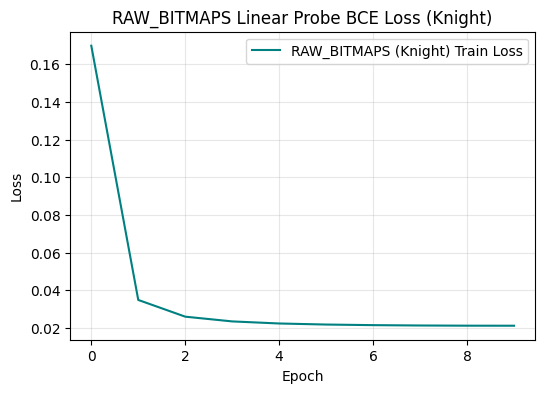


Processing Probe: RAW_BITMAPS -> BISHOP
[RAW_BITMAPS - bishop] No probe found. Starting training...
Starting Probe Training on CUDA...


Epoch [01/10]: 100%|██████████| 8999/8999 [10:11<00:00, 14.70it/s, f1=80.83%, loss=0.118]


Epoch [01/10] | Train Loss: 0.2391 | F1: 75.34% | LR: 1.00e-03



Epoch [02/10]: 100%|██████████| 8999/8999 [10:20<00:00, 14.49it/s, f1=82.82%, loss=0.0815]


Epoch [02/10] | Train Loss: 0.0956 | F1: 81.89% | LR: 9.76e-04



...

Epoch [08/10] | Train Loss: 0.0789 | F1: 83.91% | LR: 2.07e-04



Epoch [09/10]: 100%|██████████| 8999/8999 [10:44<00:00, 13.96it/s, f1=82.76%, loss=0.0815]


Epoch [09/10] | Train Loss: 0.0788 | F1: 83.93% | LR: 9.64e-05



Epoch [10/10]: 100%|██████████| 8999/8999 [10:49<00:00, 13.85it/s, f1=84.42%, loss=0.0747]

Epoch [10/10] | Train Loss: 0.0787 | F1: 83.94% | LR: 2.54e-05

[RAW_BITMAPS - bishop] Logged Final F1: 83.94% to experiments\logs\raw_bitmaps\probe_f1_scores.csv


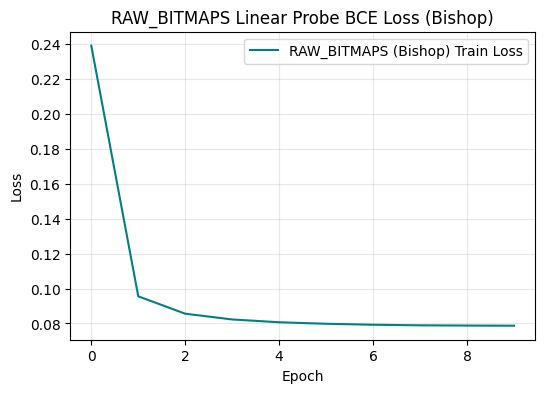


Processing Probe: RAW_BITMAPS -> ROOK
[RAW_BITMAPS - rook] No probe found. Starting training...
Starting Probe Training on CUDA...


Epoch [01/10]: 100%|██████████| 8999/8999 [11:44<00:00, 12.77it/s, f1=80.00%, loss=0.124]


Epoch [01/10] | Train Loss: 0.2564 | F1: 76.47% | LR: 1.00e-03



Epoch [02/10]: 100%|██████████| 8999/8999 [11:43<00:00, 12.79it/s, f1=80.30%, loss=0.129]


Epoch [02/10] | Train Loss: 0.1332 | F1: 81.75% | LR: 9.76e-04



...

Epoch [08/10] | Train Loss: 0.1146 | F1: 83.09% | LR: 2.07e-04



Epoch [09/10]: 100%|██████████| 8999/8999 [11:29<00:00, 13.06it/s, f1=84.95%, loss=0.0922]


Epoch [09/10] | Train Loss: 0.1144 | F1: 83.09% | LR: 9.64e-05



Epoch [10/10]: 100%|██████████| 8999/8999 [11:28<00:00, 13.06it/s, f1=83.39%, loss=0.108] 

Epoch [10/10] | Train Loss: 0.1143 | F1: 83.10% | LR: 2.54e-05

[RAW_BITMAPS - rook] Logged Final F1: 83.10% to experiments\logs\raw_bitmaps\probe_f1_scores.csv


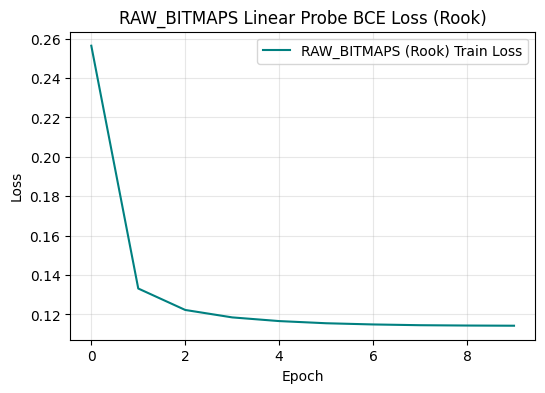


Processing Probe: RAW_BITMAPS -> QUEEN
[RAW_BITMAPS - queen] No probe found. Starting training...
Starting Probe Training on CUDA...


Epoch [01/10]: 100%|██████████| 8999/8999 [10:25<00:00, 14.38it/s, f1=82.71%, loss=0.18] 


Epoch [01/10] | Train Loss: 0.2521 | F1: 75.30% | LR: 1.00e-03



Epoch [02/10]: 100%|██████████| 8999/8999 [10:20<00:00, 14.50it/s, f1=83.00%, loss=0.157]


Epoch [02/10] | Train Loss: 0.1515 | F1: 80.62% | LR: 9.76e-04



...

Epoch [08/10] | Train Loss: 0.1396 | F1: 81.38% | LR: 2.07e-04



Epoch [09/10]: 100%|██████████| 8999/8999 [10:29<00:00, 14.29it/s, f1=82.95%, loss=0.114]


Epoch [09/10] | Train Loss: 0.1395 | F1: 81.39% | LR: 9.64e-05



Epoch [10/10]: 100%|██████████| 8999/8999 [10:32<00:00, 14.22it/s, f1=85.42%, loss=0.113]

Epoch [10/10] | Train Loss: 0.1394 | F1: 81.40% | LR: 2.54e-05

[RAW_BITMAPS - queen] Logged Final F1: 81.40% to experiments\logs\raw_bitmaps\probe_f1_scores.csv


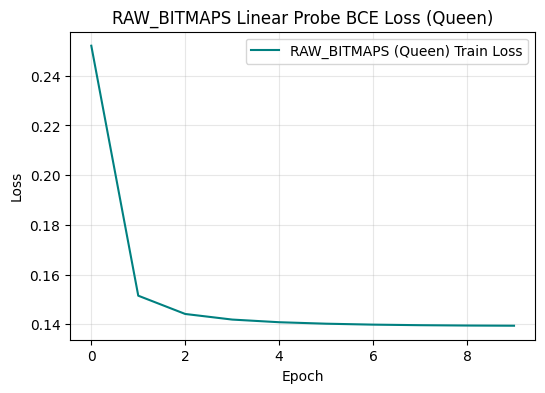

In [19]:
# ==========================================
# Train or Load Probes
# ==========================================
for model_key in Config.ACTIVE_PROBES:
    setup = MODEL_REGISTRY[model_key]

    if model_key == "RAW_BITMAPS":
        print(f"\n[{model_key}] Setting up raw baseline...")
        model = None
        latent_dim = 775 # Size of the 1D chess bitmap
    else:    
        model = load_model(setup, model_key)

        # Load the heavy base model ONCE per architecture
        model_path = MODEL_DIR / f"{setup['name']}.pth"
        try:
            model.load_state_dict(torch.load(model_path))
        except FileNotFoundError:
            print(f"\n[{model_key}] Base weight file not found at {model_path}. Skipping entirely.")
            continue

        # Get the latent dimension ONCE per architecture
        dummy_shape = (1, 19, 8, 8) if setup['is_3d'] else (1, 775)
        dummy_x = torch.zeros(dummy_shape).to(DEVICE)
        dummy_extractor = LatentExtractor(model, model_key)
        dummy_latent = dummy_extractor.extract(dummy_x)
        latent_dim = dummy_latent.flatten(1).shape[1] 
        dummy_extractor.remove_hook()
        
    for current_piece in Config.PROBE_PIECES:
        piece_str = chess.piece_name(current_piece).lower()
        print(f"\n{'='*50}\nProcessing Probe: {model_key} -> {piece_str.upper()}\n{'='*50}")

        model_log_dir = LOGS_DIR / setup['name']
        model_log_dir.mkdir(parents=True, exist_ok=True) 
        probe_save_path = MODEL_DIR / f"{setup['name']}_{piece_str}_linear_probe.pth"

        probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)

        if probe_save_path.exists():
            print(f"[{model_key} - {piece_str}] Found existing probe. Loading weights...")
            probe.load_state_dict(torch.load(probe_save_path))
        else:
            print(f"[{model_key} - {piece_str}] No probe found. Starting training...")
            
            # Pass the specific piece to the dataset
            train_probe_dataset = LegalMoveProbeDataset(
                npy_dir=setup['dataset_dir'], 
                parquet_path=DATASET_READY_DIR, 
                split="train",
                piece_type=current_piece
            )
            train_probe_dataloader = DataLoader(train_probe_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

            current_weight = Config.PIECE_WEIGHTS.get(current_piece, 1.0)

            loss_history, f1_score = train_probe_loop(
                base_model=model,
                model_key=model_key,
                probe=probe,
                dataloader=train_probe_dataloader,
                pos_weight=current_weight, 
                epochs=Config.EPOCHS,
                lr=Config.LEARNING_RATE
            )
            
            torch.save(probe.state_dict(), probe_save_path)
            
            log_path = model_log_dir / "probe_f1_scores.csv"
            file_exists = log_path.exists()
            with open(log_path, mode="a", newline="") as f:
                writer = csv.writer(f)
                if not file_exists:
                    writer.writerow(["Model_Key", "Weights_File", "Piece", "Final_F1"]) 
                writer.writerow([model_key, setup['name'], piece_str.title(), f"{f1_score*100:.2f}%"])
                
            print(f"[{model_key} - {piece_str}] Logged Final F1: {f1_score*100:.2f}% to {log_path}")

            plt.figure(figsize=(6, 4))
            plt.plot(loss_history, label=f'{model_key} ({piece_str.title()}) Train Loss', color='teal')
            plt.title(f"{model_key} Linear Probe BCE Loss ({piece_str.title()})")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()


Visualizing KNIGHT Probes
Analyzing legal moves for knight at: E3
RAW_BITMAPS Knight Probe (E3)


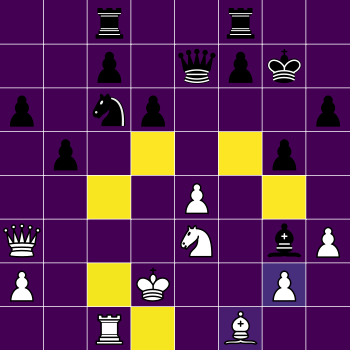


Visualizing BISHOP Probes
Analyzing legal moves for bishop at: F1
RAW_BITMAPS Bishop Probe (F1)


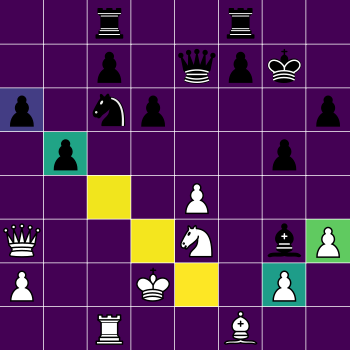


Visualizing ROOK Probes
Analyzing legal moves for rook at: C1
RAW_BITMAPS Rook Probe (C1)


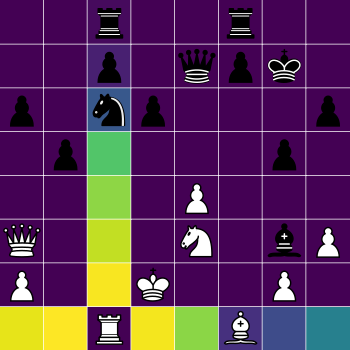


Visualizing QUEEN Probes
Analyzing legal moves for queen at: A3
RAW_BITMAPS Queen Probe (A3)


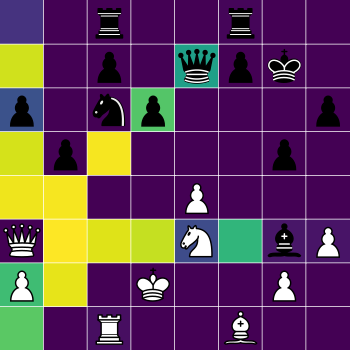

: 

In [ ]:
# ==========================================
# Forward Pass & Heatmap Visualization
# ==========================================
board = chess.Board(Config.TEST_FEN)

for current_piece in Config.PROBE_PIECES:
    piece_str = chess.piece_name(current_piece).lower()
    print(f"\n{'='*50}\nVisualizing {piece_str.upper()} Probes\n{'='*50}")

    if Config.TARGET_SQUARE is not None:
        target_square = Config.TARGET_SQUARE
    else:
        pieces = list(board.pieces(current_piece, board.turn))
        if not pieces:
            print(f"No {piece_str}s found on the board for the side to move. Skipping.")
            continue
        target_square = random.choice(pieces)

    square_name = chess.square_name(target_square)
    print(f"Analyzing legal moves for {piece_str} at: {square_name.upper()}")

    for model_key in Config.ACTIVE_PROBES:
        setup = MODEL_REGISTRY[model_key]
        if model_key == "RAW_BITMAPS":
            extractor = None
            latent_dim = 775
        else:
            model = load_model(setup, model_key) 
                
            model_path = MODEL_DIR / f"{setup['name']}.pth" 
            if not model_path.exists(): 
                print(f"\n[{model_key}] Base model not found at {model_path}. Skipping.")
                continue
                
            model.load_state_dict(torch.load(model_path))
            model.eval() 
            
            # Setup Extractor & Find Latent Dimension
            extractor = LatentExtractor(model, model_key) 
            dummy_shape = (1, 19, 8, 8) if setup['is_3d'] else (1, 775) 
            dummy_x = torch.zeros(dummy_shape).to(DEVICE) 
            latent_dim = extractor.extract(dummy_x).flatten(1).shape[1]
            
        # Load the specific probe for this piece and model
        probe_save_path = MODEL_DIR / f"{setup['name']}_{piece_str}_linear_probe.pth"
        
        if not probe_save_path.exists():
            print(f"\n[{model_key}] Probe not found at {probe_save_path}. Skipping.")
            if extractor is not None: 
                extractor.remove_hook() 
            continue
            
        probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)
        probe.load_state_dict(torch.load(probe_save_path))
        probe.eval()
        
        # Prepare Input Tensor
        raw_tensor = fen_to_tensor(Config.TEST_FEN) if setup['is_3d'] else fen_to_vector(Config.TEST_FEN)
        x_tensor = torch.tensor(raw_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        
        # Extract Latent Vector
        if model_key == "RAW_BITMAPS":
            latent = x_tensor.flatten(1)
        else:
            latent = extractor.extract(x_tensor) 
            if latent.dim() > 2: 
                latent = latent.flatten(1) 
            
        # Prepare Query Mask (The address of the piece)
        piece_loc_mask = np.zeros(64, dtype=np.float32)
        piece_loc_mask[target_square] = 1.0
        piece_loc_tensor = torch.tensor(piece_loc_mask).unsqueeze(0).to(DEVICE)
        
        # Predict & Plot
        with torch.no_grad():
            raw_logits = probe(latent, piece_loc_tensor)
            predicted_mask_prob = torch.sigmoid(raw_logits).cpu().numpy()[0] 
            
        title = f"{model_key} {piece_str.title()} Probe ({square_name.upper()})"
        render_heatmap_svg(predicted_mask_prob, Config.TEST_FEN, title, display_svg=True)
        
        if extractor is not None:
            extractor.remove_hook() 